Logistic Regression Accuracy: 0.97
Random Forest Accuracy: 0.96
SVM Accuracy: 0.96


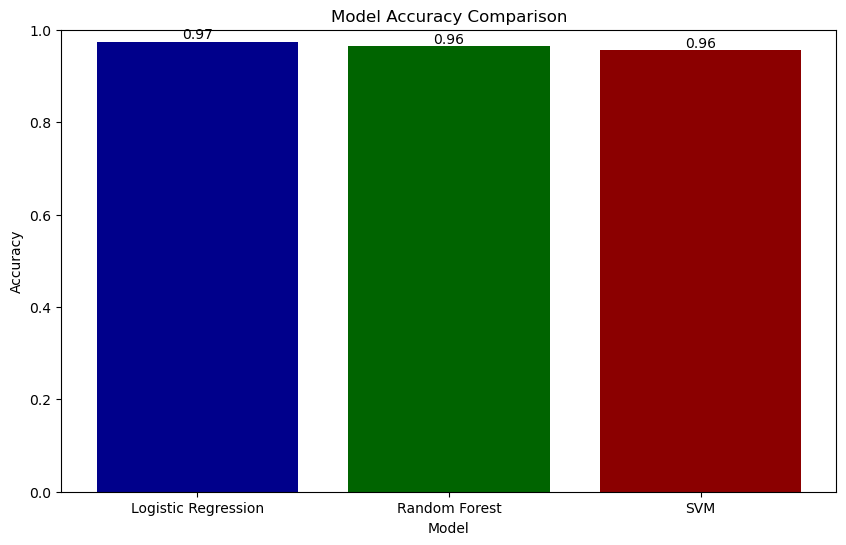

In [34]:
#import necessary libraries
import sklearn.datasets
import sklearn.linear_model
import sklearn.metrics
import sklearn.model_selection
import sklearn.pipeline
import sklearn.preprocessing
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the breast cancer dataset
data = sklearn.datasets.load_breast_cancer()

# Create a DataFrame for easier analysis
df = pd.DataFrame(data.data, columns=data.feature_names)



# Split the data into features and target
X = df
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with a scaler and logistic regression
pipeline = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('classifier', sklearn.linear_model.LogisticRegression())
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)

#compare the accuracy by using a different model (e.g., Random Forest)
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline with a scaler and random forest classifier
pipeline_rf = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


# Train the random forest model
pipeline_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate the random forest model
accuracy_rf = sklearn.metrics.accuracy_score(y_test, y_pred_rf)
 

# find a third model to train the data and compare the results
from sklearn.svm import SVC
# Create a pipeline with a scaler and SVM classifier
pipeline_svm = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('classifier', SVC(kernel='linear', random_state=42))
])


# Train the SVM model 
pipeline_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = pipeline_svm.predict(X_test)


# Evaluate the SVM model
accuracy_svm = sklearn.metrics.accuracy_score(y_test, y_pred_svm)

#compare the 3 models
print(f"Logistic Regression Accuracy: {accuracy:.2f}")
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"SVM Accuracy: {accuracy_svm:.2f}")


# Create a plot to compare the accuracies of the three models making sure that the colours are dark and different to each other while making sure numbers are visible on the bars
model_names = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies = [accuracy, accuracy_rf, accuracy_svm] 
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['darkblue', 'darkgreen', 'darkred'])
plt.ylim(0,1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')

# Add accuracy values outside the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval +0.00, f'{yval:.2f}', ha='center', va='bottom')


